# Customer Segmentation Using Data Science, Artificial Intelligence, and Machine Learning with Python
### Name: Pratham Mishra, Rupanwita Garai, Hardik Prasad
### Date: May 31, 2025


## 1. Introduction
Customer segmentation is the practice of dividing a customer base into groups that are similar in specific ways, such as age, gender, income, interests, or spending habits. In this project, we use machine learning (K-Means clustering) to analyze and group customers based on their behavior. This helps businesses target specific segments for marketing and improve customer satisfaction.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


## 2. Loading the Dataset

We upload and read the Excel dataset `customers.xlsx` into a pandas DataFrame using `read_excel()`. This dataset contains details such as Customer ID, Gender, Age, Annual Income, and Spending Score. We will use this data to perform customer segmentation using machine learning techniques.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customers.xlsx to customers.xlsx


In [ ]:
df = pd.read_excel('customers.xlsx')
df.head()

,customerNumber,customerName,contactLastName,contactFirstName,phone,addressLine1,addressLine2,city,state,postalCode,country,salesRepEmployeeNumber,creditLimit
0,103,Atelier graphique,Schmitt,Carine,40.32.2555,"54, rue Royale",NaN,Nantes,NaN,44000,France,1370.0,21000
1,112,Signal Gift Stores,King,Jean,7025551838,8489 Strong St.,NaN,Las Vegas,NV,83030,USA,1166.0,71800
2,114,"Australian Collectors, Co.",Ferguson,Peter,03 9520 4555,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,1611.0,117300
3,119,La Rochelle Gifts,Labrune,Janine,40.67.8555,"67, rue des Cinquante Otages",NaN,Nantes,NaN,44000,France,1370.0,118200
4,121,Baane Mini Imports,Bergulfsen,Jonas,07-98 9555,Erling Skakkes gate 78,NaN,Stavern,NaN,4110,Norway,1504.0,81700


## 3. Exploratory Data Analysis (EDA)

In this section, we will perform an initial investigation of the dataset to discover patterns, spot anomalies, and check assumptions using statistical summaries and visualizations.


In [ ]:
print("🔹 First 5 rows of the dataset:")
print(df.head(), "\n")

print("🔹 Shape of the dataset (rows, columns):", df.shape, "\n")

print("🔹 Column names and data types:")
print(df.dtypes, "\n")

print("🔹 Summary statistics for numerical columns:")
print(df.describe(), "\n")

print("🔹 Missing values in each column:")
print(df.isnull().sum())

🔹 First 5 rows of the dataset:
   customerNumber                customerName contactLastName  \
0             103           Atelier graphique         Schmitt   
1             112          Signal Gift Stores            King   
2             114  Australian Collectors, Co.        Ferguson   
3             119           La Rochelle Gifts         Labrune   
4             121          Baane Mini Imports      Bergulfsen   

  contactFirstName         phone                  addressLine1 addressLine2  \
0          Carine     40.32.2555                54, rue Royale          NaN   
1             Jean    7025551838               8489 Strong St.          NaN   
2            Peter  03 9520 4555             636 St Kilda Road      Level 3   
3          Janine     40.67.8555  67, rue des Cinquante Otages          NaN   
4           Jonas     07-98 9555        Erling Skakkes gate 78          NaN   

        city     state postalCode    country  salesRepEmployeeNumber  \
0     Nantes       NaN      440

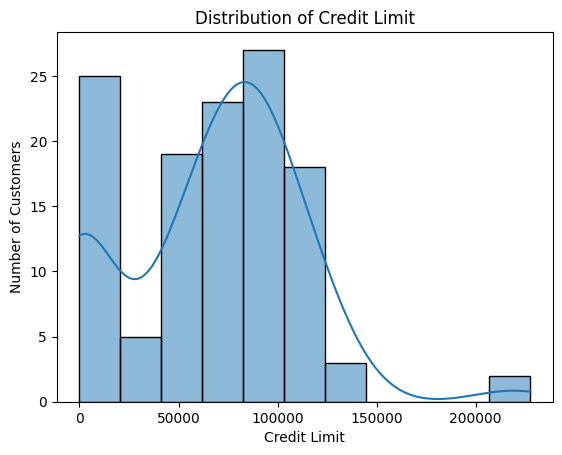

In [ ]:
sns.histplot(df['creditLimit'], kde=True)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")
plt.show()

## 4. Data Preprocessing

We select the `creditLimit` feature, handle missing values, and scale the data to prepare it for clustering.


In [ ]:
X = df[['creditLimit']].copy()

print("Missing values in selected features:\n", X.isnull().sum())

X.dropna(inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled creditLimit values (first 5 rows):")
print(X_scaled[:5])


Missing values in selected features:
 creditLimit    0
dtype: int64

Scaled creditLimit values (first 5 rows):
[[-1.04014031]
 [ 0.09231236]
 [ 1.10661544]
 [ 1.12667858]
 [ 0.31300688]]


## 5. Customer Segmentation with K-Means

We use the K-Means clustering algorithm to group customers into clusters based on their credit limits. First, we determine the optimal number of clusters using the Elbow Method, and then visualize the segmentation.


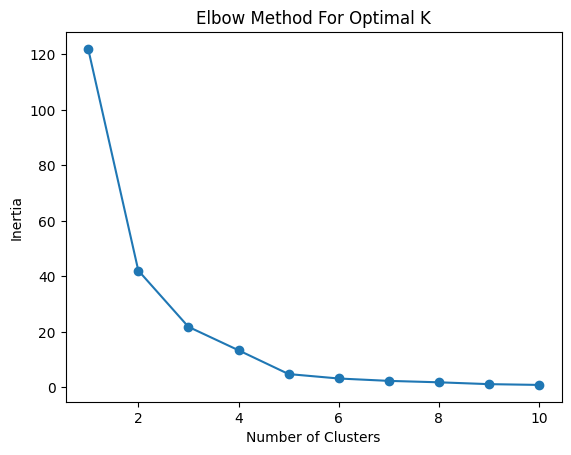

In [ ]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df[['creditLimit', 'Cluster']].head())

   creditLimit  Cluster
0        21000        1
1        71800        2
2       117300        0
3       118200        0
4        81700        2


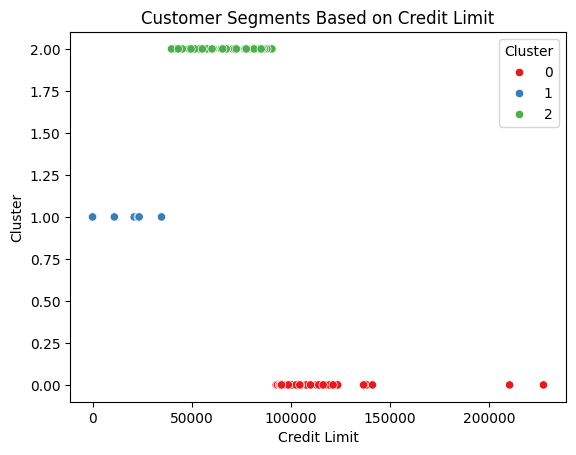

In [ ]:
sns.scatterplot(x='creditLimit', y='Cluster', data=df, hue='Cluster', palette='Set1')
plt.title('Customer Segments Based on Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Cluster')
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df[['country', 'creditLimit']].dropna(), drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

summary = df[['customerName', 'country', 'creditLimit', 'Cluster']].head()
summary

,customerName,country,creditLimit,Cluster
0,Atelier graphique,France,21000,0
1,Signal Gift Stores,USA,71800,0
2,"Australian Collectors, Co.",Australia,117300,0
3,La Rochelle Gifts,France,118200,0
4,Baane Mini Imports,Norway,81700,0


from matplotlib import pyplot as plt
summary['creditLimit'].plot(kind='hist', bins=20, title='creditLimit')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
summary.groupby('customerName').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
summary.groupby('country').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Cluster']
  ys = series['creditLimit']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = summary.sort_values('Cluster', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('customerName')):
  _plot_series(series, series_name, i)
  fig.legend(title='customerName', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Cluster')
_ = plt.ylabel('creditLimit')

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['country'].value_counts()
    for x_label, grp in summary.groupby('customerName')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('customerName')
_ = plt.ylabel('country')

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(summary['customerName'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(summary, x='creditLimit', y='customerName', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(summary['country'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(summary, x='creditLimit', y='country', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

### Customer Segmentation Summary

This section summarizes customer groups formed by K-Means clustering based on:

- Gender, Age, Income, and Spending Score  
- Shows average values per cluster  
- Helps identify patterns like high spenders, young low spenders, etc.

Use this for targeted marketing and personalized strategies.